# Passive Coating Outdoor Temperature — EDA
**Dataset:** 24-hour outdoor measurement, 2026-04-27 (1-min intervals, 1440 rows)

**Goal:** Understand temperature and sub-ambient ΔT behaviour of 20 coating samples vs a bare reference.

**Sample IDs:** REF = bare substrate reference · S01–S19 = coating formulations (anonymized)

`dT_*` columns = sample °C − REF °C  (negative = cooler than reference = good performance)

## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv('../data/raw/outdoor_temp_2026-04-27.csv', parse_dates=['Time'])
df = df.set_index('Time').sort_index()
raw_cols = [c for c in df.columns if not c.startswith('dT_')]
sub_cols = [c for c in df.columns if c.startswith('dT_')]
print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0]}  to  {df.index[-1]}')
print(f'Raw temp cols ({len(raw_cols)}): {raw_cols}')
print(f'DeltaT cols   ({len(sub_cols)}): {sub_cols}')
df.head(3)

Shape: (1440, 40)
Date range: 2026-04-27 00:00:51.020000  to  2026-04-27 23:59:51.020000
Raw temp cols (20): ['REF', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19']
DeltaT cols   (20): ['dT_REF', 'dT_S01', 'dT_S02', 'dT_S03', 'dT_S04', 'dT_S05', 'dT_S06', 'dT_S07', 'dT_S08', 'dT_S09', 'dT_S10', 'dT_S11', 'dT_S12', 'dT_S13', 'dT_S14', 'dT_S15', 'dT_S16', 'dT_S17', 'dT_S18', 'dT_S19']


,REF,S01,S02,S03,S04,S05,S06,S07,S08,S09,...,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
Time,,,,,,,,,,,,,,,,,,,,,
2026-04-27 00:00:51.020,29.004722,29.054201,28.984083,28.939659,29.109575,29.128275,28.964797,29.007482,29.086226,28.959246,...,0.081013,-0.067598,0.005831,0.009028,-0.008656,-0.158735,-0.173906,-0.008475,-0.151066,-0.182778
2026-04-27 00:01:51.020,28.972220,29.052183,29.017903,28.994553,29.104128,29.126188,28.956843,28.997880,29.089881,28.959999,...,0.151951,-0.040091,-0.017816,0.022455,0.030615,-0.127828,-0.124845,0.017172,-0.118597,-0.176970
2026-04-27 00:02:51.020,28.979273,29.033164,29.003532,28.917711,29.093664,29.120790,28.956897,28.989343,29.083269,28.941577,...,0.161360,-0.052998,-0.019174,0.012517,0.023716,-0.127320,-0.143367,0.075447,-0.120459,-0.170453


## 2. Basic Statistics

In [2]:
print('--- Raw temperature summary (degC) ---')
display(df[raw_cols].describe().round(2))
print('--- DeltaT summary (degC, relative to REF) ---')
df[sub_cols].describe().round(3)

--- Raw temperature summary (degC) ---


,REF,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,S13,S14,S15,S16,S17,S18,S19
count,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00
mean,35.09,33.57,33.50,33.64,33.57,33.52,33.52,33.55,33.59,33.42,33.63,33.63,33.65,33.40,33.47,33.36,33.52,33.43,33.42,33.25
std,7.53,5.50,5.47,5.76,5.39,5.33,5.51,5.55,5.48,5.43,5.48,5.71,5.70,5.33,5.44,5.46,5.72,5.39,5.52,5.40
min,27.96,28.02,27.95,27.87,28.07,28.08,27.93,27.97,28.05,27.92,28.04,27.89,27.92,27.96,27.95,27.81,27.79,27.93,27.80,27.76
25%,28.81,28.85,28.80,28.73,28.92,28.94,28.78,28.81,28.89,28.76,28.91,28.74,28.78,28.83,28.83,28.68,28.66,28.83,28.67,28.63
50%,30.02,30.02,29.96,29.88,30.11,30.09,29.90,29.93,30.02,29.89,30.08,29.89,29.91,29.96,29.96,29.78,29.76,29.98,29.81,29.73
75%,42.25,39.06,39.00,39.40,38.93,38.94,39.19,39.06,39.10,38.88,39.32,39.40,39.41,38.80,38.86,38.99,39.16,38.73,39.12,38.70
max,50.01,44.03,43.71,44.62,43.69,43.56,43.82,44.15,44.05,43.81,43.93,44.49,44.39,43.46,43.90,43.67,44.52,43.81,43.86,43.58


--- DeltaT summary (degC, relative to REF) ---


,dT_REF,dT_S01,dT_S02,dT_S03,dT_S04,dT_S05,dT_S06,dT_S07,dT_S08,dT_S09,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
count,1440.0,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000
mean,0.0,-1.520,-1.592,-1.455,-1.529,-1.573,-1.579,-1.546,-1.504,-1.675,-1.462,-1.461,-1.448,-1.695,-1.620,-1.733,-1.570,-1.660,-1.674,-1.841
std,0.0,2.103,2.135,1.844,2.224,2.266,2.076,2.050,2.105,2.168,2.110,1.893,1.900,2.280,2.198,2.125,1.894,2.255,2.070,2.196
min,0.0,-6.322,-6.342,-5.666,-6.635,-6.548,-6.186,-6.312,-6.228,-6.530,-6.106,-5.666,-5.734,-6.908,-6.752,-6.399,-6.059,-6.947,-6.308,-6.953
25%,0.0,-3.372,-3.448,-3.088,-3.517,-3.553,-3.360,-3.371,-3.367,-3.572,-3.199,-3.092,-3.086,-3.673,-3.495,-3.526,-3.248,-3.643,-3.430,-3.741
50%,0.0,-0.001,-0.070,-0.134,0.085,0.050,-0.124,-0.087,-0.005,-0.147,0.054,-0.121,-0.113,-0.069,-0.048,-0.246,-0.250,-0.054,-0.213,-0.275
75%,0.0,0.056,-0.012,-0.078,0.117,0.129,-0.032,0.001,0.088,-0.041,0.089,-0.062,-0.031,0.013,0.022,-0.138,-0.148,0.028,-0.126,-0.176
max,0.0,0.134,0.097,0.203,0.308,0.194,0.005,0.059,0.169,-0.006,0.178,0.225,0.156,0.097,0.366,-0.085,0.199,0.294,0.031,-0.111


## 3. Data Quality Check

In [3]:
missing = df.isnull().sum()
print('Missing values:', 'None' if missing.sum()==0 else missing[missing>0].to_dict())
diffs = df.index.to_series().diff().dropna()
gaps = diffs[diffs != pd.Timedelta('1min')]
print(f'Time-interval gaps (expect 1 min): {len(gaps)} found')
if not gaps.empty: print(gaps)

Missing values: None
Time-interval gaps (expect 1 min): 12 found
Time
2026-04-27 09:04:51.035   0 days 00:01:00.015000
2026-04-27 09:05:51.020   0 days 00:00:59.985000
2026-04-27 10:36:51.059   0 days 00:01:00.039000
2026-04-27 10:37:51.020   0 days 00:00:59.961000
2026-04-27 12:08:51.021   0 days 00:01:00.001000
2026-04-27 12:09:51.020   0 days 00:00:59.999000
2026-04-27 13:39:51.075   0 days 00:01:00.055000
2026-04-27 13:40:51.020   0 days 00:00:59.945000
2026-04-27 15:14:51.059   0 days 00:01:00.039000
2026-04-27 15:15:51.020   0 days 00:00:59.961000
2026-04-27 19:49:51.029   0 days 00:01:00.009000
2026-04-27 19:50:51.020   0 days 00:00:59.991000
Name: Time, dtype: timedelta64[us]


## 4. 24-Hour Temperature Profiles

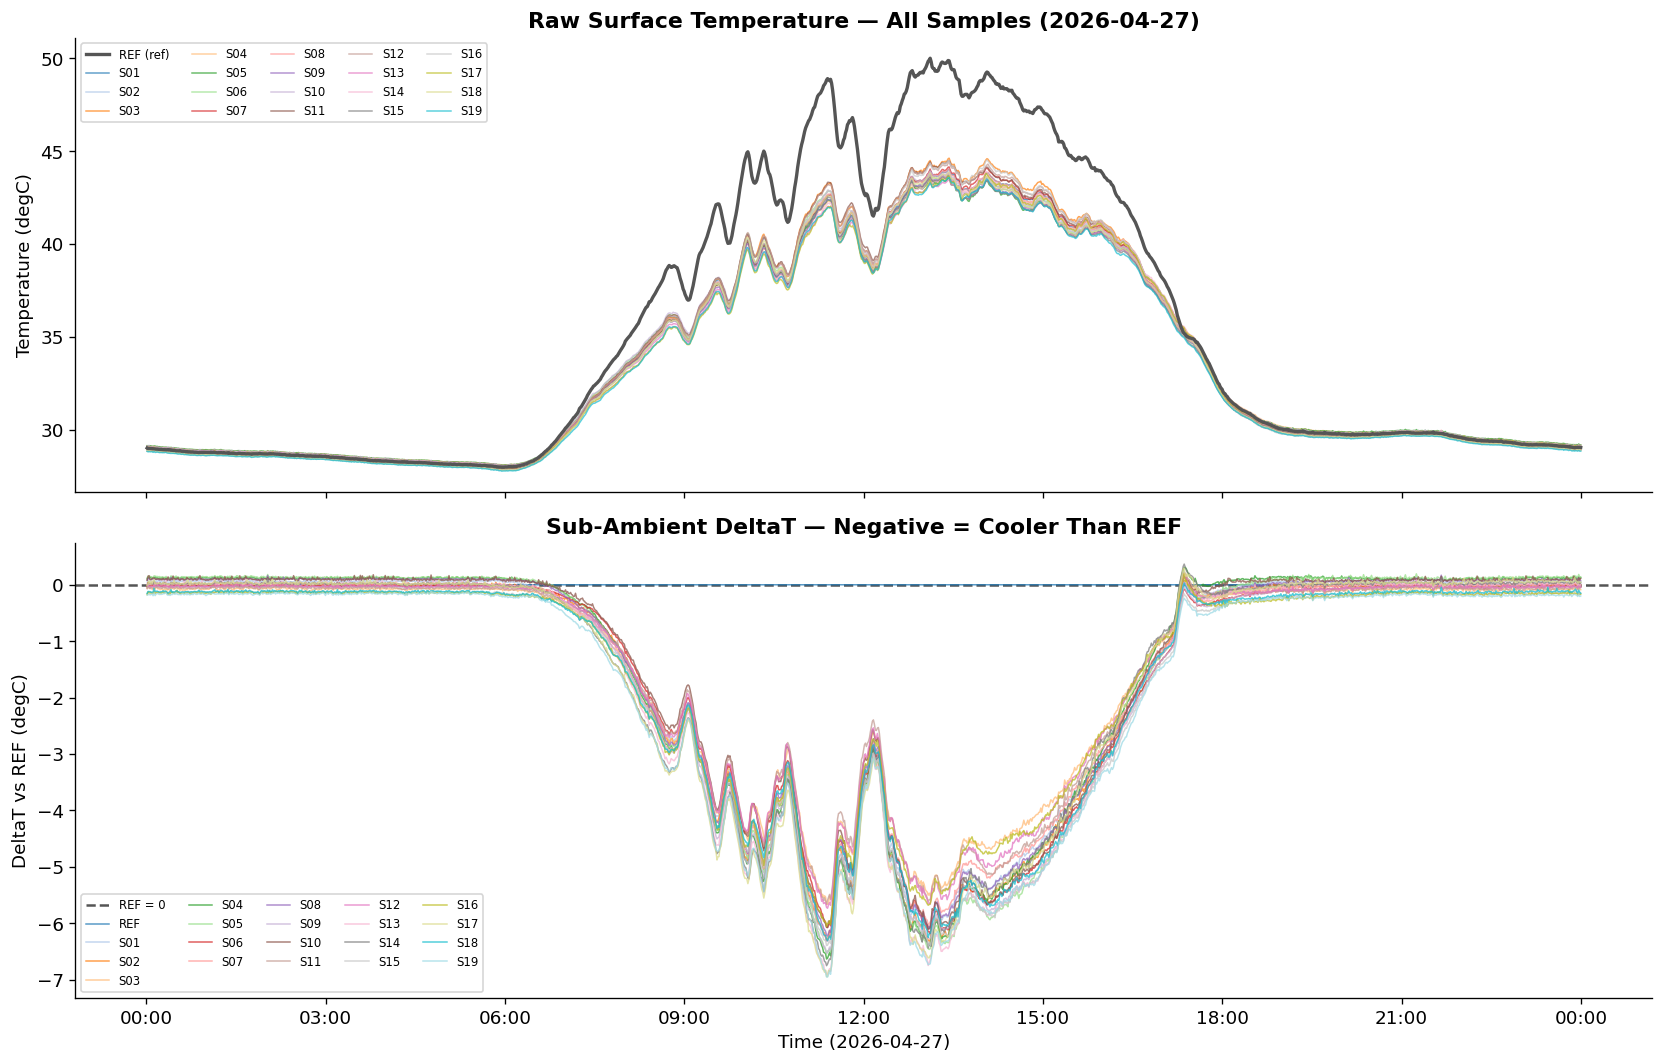

Saved: 01_temperature_profiles.png


In [4]:
fig, axes = plt.subplots(2,1,figsize=(14,9),sharex=True)
palette = plt.cm.tab20.colors

ax1 = axes[0]
ax1.plot(df.index, df['REF'], color='#555', lw=2, label='REF (ref)', zorder=5)
for i,col in enumerate(raw_cols[1:]):
    ax1.plot(df.index, df[col], lw=0.9, alpha=0.7, color=palette[i], label=col)
ax1.set_ylabel('Temperature (degC)')
ax1.set_title('Raw Surface Temperature — All Samples (2026-04-27)', fontweight='bold')
ax1.legend(fontsize=7, ncol=5, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax2 = axes[1]
ax2.axhline(0, color='#555', lw=1.5, ls='--', label='REF = 0')
for i,col in enumerate(sub_cols):
    ax2.plot(df.index, df[col], lw=0.9, alpha=0.75, color=palette[i], label=col.replace('dT_',''))
ax2.set_ylabel('DeltaT vs REF (degC)')
ax2.set_xlabel('Time (2026-04-27)')
ax2.set_title('Sub-Ambient DeltaT — Negative = Cooler Than REF', fontweight='bold')
ax2.legend(fontsize=7, ncol=5, loc='lower left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.savefig(FIGURES/'01_temperature_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: 01_temperature_profiles.png')

## 5. Peak Cooling Performance (Daytime 06:00–18:00)

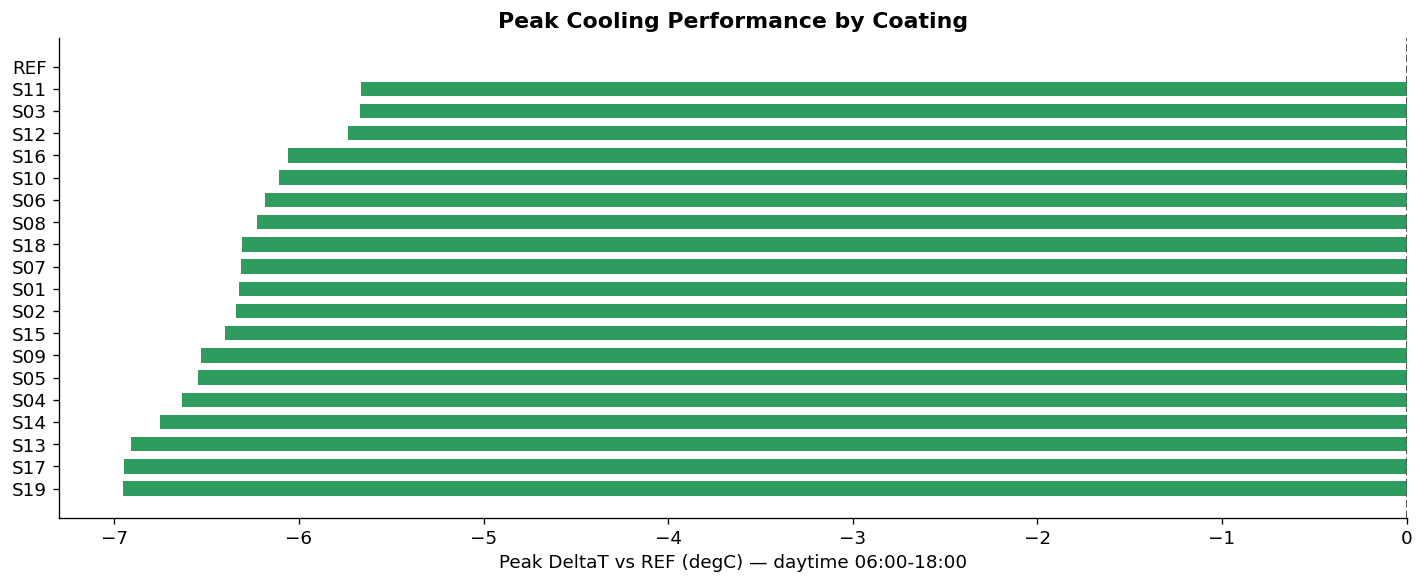

Top 5 coolest coatings:
S19   -6.953080
S17   -6.947077
S13   -6.907753
S14   -6.751760
S04   -6.634634


In [5]:
daytime  = df.between_time('06:00','18:00')
nighttime = df.between_time('19:00','05:59')

peak = daytime[sub_cols].min().sort_values()
peak.index = [c.replace('dT_','') for c in peak.index]

fig, ax = plt.subplots(figsize=(12,5))
colors = ['#2d9c5e' if v<-0.5 else '#e3b341' if v<0 else '#e05c4b' for v in peak.values]
bars = ax.barh(peak.index, peak.values, color=colors, height=0.65)
ax.axvline(0, color='#555', lw=1.2, ls='--')
for bar,val in zip(bars,peak.values):
    ax.text(val-0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}C',
            va='center', ha='right', fontsize=8, color='white', fontweight='bold')
ax.set_xlabel('Peak DeltaT vs REF (degC) — daytime 06:00-18:00')
ax.set_title('Peak Cooling Performance by Coating', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'02_peak_cooling_comparison.png', bbox_inches='tight')
plt.show()
print('Top 5 coolest coatings:')
print(peak.head(5).to_string())

## 6. Day vs Night Mean DeltaT

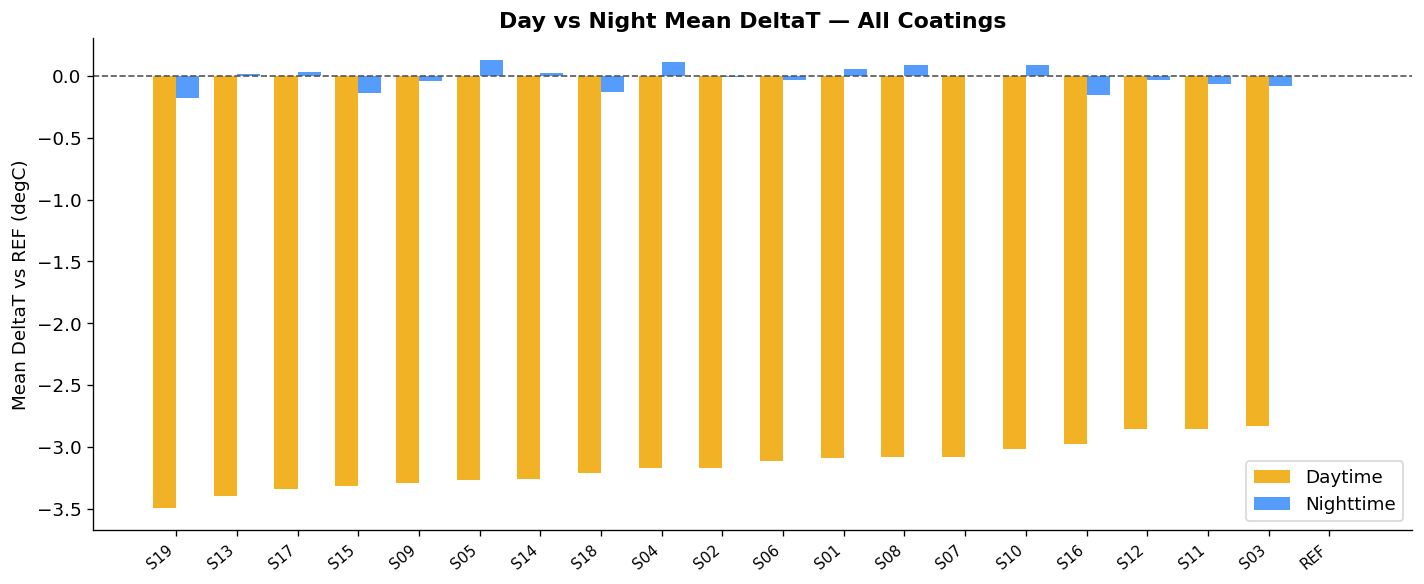

In [6]:
day_mean   = daytime[sub_cols].mean().rename(lambda c: c.replace('dT_',''))
night_mean = nighttime[sub_cols].mean().rename(lambda c: c.replace('dT_',''))
comp = pd.DataFrame({'Day (06-18h)':day_mean,'Night (19-06h)':night_mean}).sort_values('Day (06-18h)')

fig,ax = plt.subplots(figsize=(12,5))
x = np.arange(len(comp)); w=0.38
ax.bar(x-w/2, comp['Day (06-18h)'],   width=w, label='Daytime',  color='#f0a500', alpha=0.85)
ax.bar(x+w/2, comp['Night (19-06h)'], width=w, label='Nighttime',color='#388bfd', alpha=0.85)
ax.axhline(0, color='#555', lw=1, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean DeltaT vs REF (degC)')
ax.set_title('Day vs Night Mean DeltaT — All Coatings', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES/'03_day_vs_night.png', bbox_inches='tight')
plt.show()

## 7. Filler Loading Effect (Low – High Concentration)

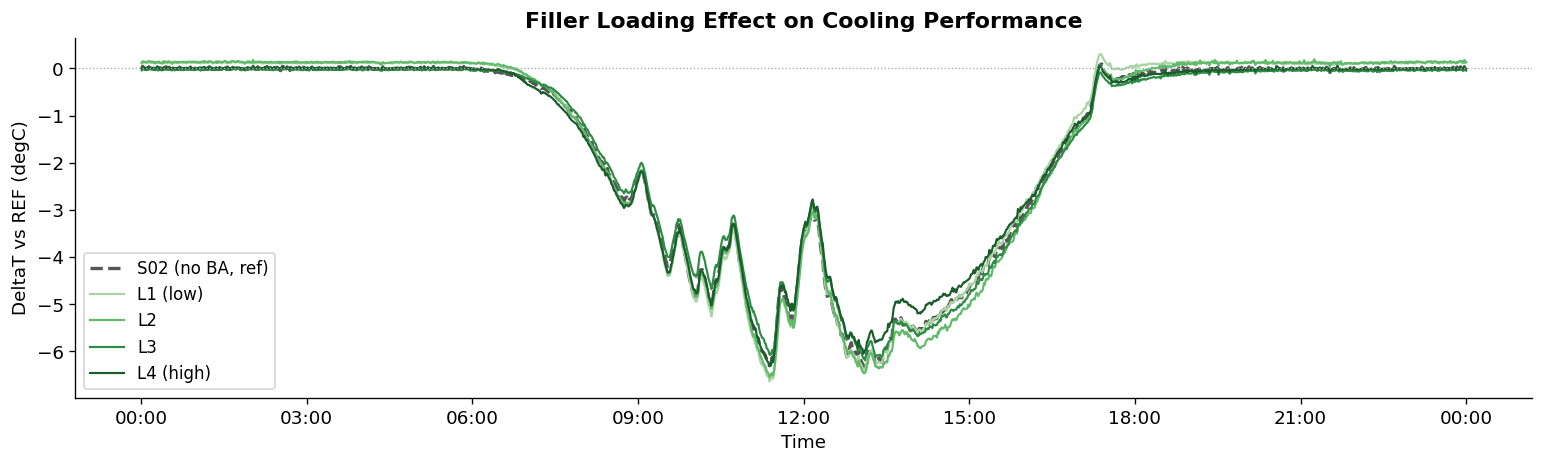

L1 (low): peak daytime DeltaT = -6.635 degC
L2: peak daytime DeltaT = -6.548 degC
L3: peak daytime DeltaT = -6.186 degC
L4 (high): peak daytime DeltaT = -6.312 degC


In [7]:
load_map = {'L1 (low)':'dT_S04','L2':'dT_S05','L3':'dT_S06','L4 (high)':'dT_S07'}
fig,ax = plt.subplots(figsize=(13,4))
ax.plot(df.index, df['dT_S02'], color='#555', lw=2, ls='--', label='S02 (no BA, ref)')
clrs = ['#a8d5a2','#5fba6a','#2d8c44','#1a5c2c']
for (label,col),c in zip(load_map.items(), clrs):
    ax.plot(df.index, df[col], lw=1.3, color=c, label=label)
ax.axhline(0, color='#aaa', lw=0.8, ls=':')
ax.set_ylabel('DeltaT vs REF (degC)')
ax.set_xlabel('Time')
ax.set_title('Filler Loading Effect on Cooling Performance', fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.savefig(FIGURES/'04_ba_loading_effect.png', bbox_inches='tight')
plt.show()
for label,col in load_map.items():
    print(f'{label}: peak daytime DeltaT = {daytime[col].min():.3f} degC')

## 8. Correlation Matrix (DeltaT across coatings)

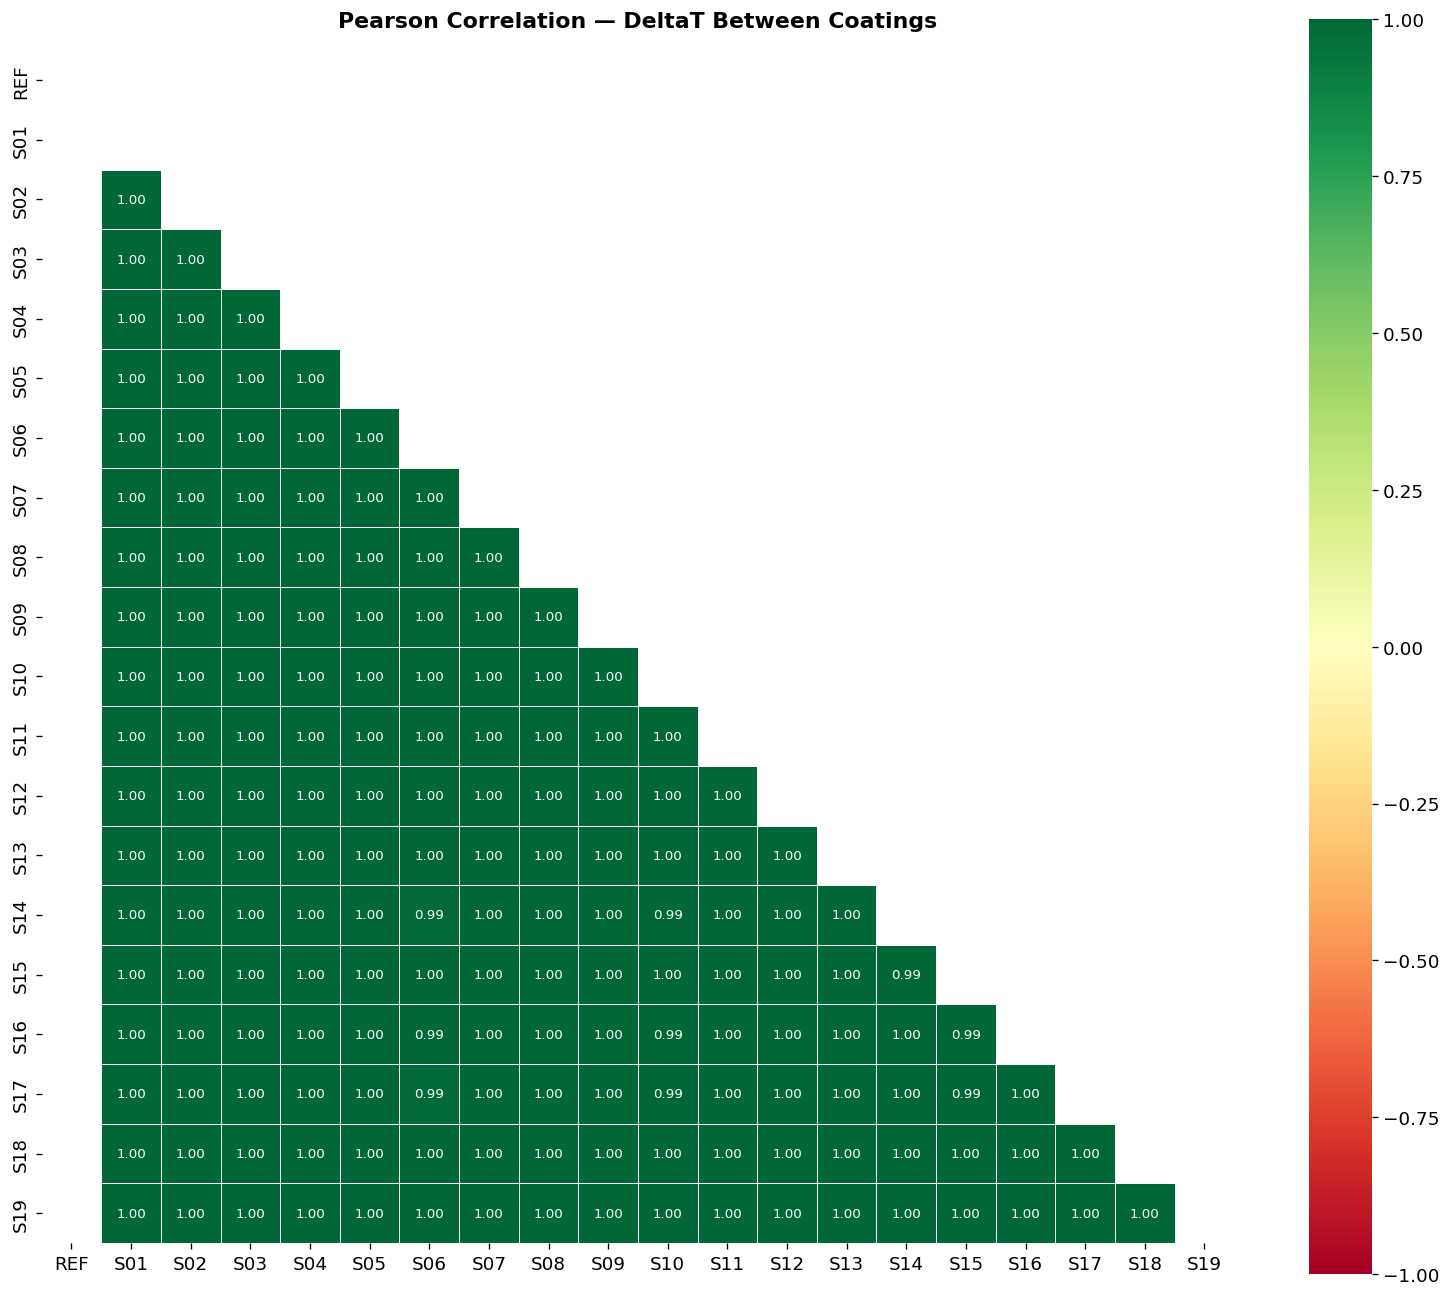

In [8]:
corr = df[sub_cols].rename(columns=lambda c: c.replace('dT_','')).corr()
fig,ax = plt.subplots(figsize=(13,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':8},
            linewidths=0.5, square=True)
ax.set_title('Pearson Correlation — DeltaT Between Coatings', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(FIGURES/'05_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 9. Summary Table

In [9]:
summary = pd.DataFrame({
    'Daytime Peak DeltaT': daytime[sub_cols].min(),
    'Daytime Mean DeltaT': daytime[sub_cols].mean(),
    'Nighttime Mean DeltaT': nighttime[sub_cols].mean(),
    'Overall Std': df[sub_cols].std(),
})
summary.index = [c.replace('dT_','') for c in summary.index]
summary.sort_values('Daytime Peak DeltaT').round(3)

,Daytime Peak DeltaT,Daytime Mean DeltaT,Nighttime Mean DeltaT,Overall Std
S19,-6.953,-3.495,-0.178,2.196
S17,-6.947,-3.343,0.033,2.255
S13,-6.908,-3.398,0.016,2.280
S14,-6.752,-3.256,0.022,2.198
S04,-6.635,-3.173,0.117,2.224
S05,-6.548,-3.268,0.130,2.266
S09,-6.530,-3.294,-0.044,2.168
S15,-6.399,-3.313,-0.141,2.125
S02,-6.342,-3.171,-0.009,2.135
S01,-6.322,-3.091,0.055,2.103


## 10. Key Findings & Next Steps

**From this EDA:**
- Dataset is 24 h outdoor measurement, 1-min resolution, no missing values or time gaps
- `dT_*` columns give ΔT vs blank directly — negative = cooler = good RC performance
- The S04–S07 concentration series shows a clear loading-dependent trend → quantifiable with ML
- Some formulations (S08, S09, S15) stay warmer than reference — high solar absorptance outweighs emission gains

**Next steps (Wednesday Block A — rc-coating-ml):**
- Feature engineering: extract daytime peak ΔT, mean ΔT, time-of-peak per sample
- Build filler-type + loading % feature matrix
- Train Random Forest → feature importance reveals which formulation parameter drives cooling